курсач



In [3]:
# Ячейка 1. Подключение Google Drive только для сохранения результатов

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Ячейка 2. Установка зависимостей

!apt-get update -y > /dev/null
!apt-get install -y unrar wget ffmpeg > /dev/null
!pip install -q pandas tqdm scikit-learn opencv-python

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [5]:
# Ячейка 3. Импорты

import os
import re
import json
import math
import time
import random
import shutil
import subprocess
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision
from torchvision import models

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

torch: 2.11.0+cu128
torchvision: 0.26.0+cu128
cuda available: True
gpu: Tesla T4


In [6]:

# Ячейка 4. Главные настройки

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
try:
    cv2.setNumThreads(0)
    cv2.ocl.setUseOpenCL(False)
except Exception as e:
    print("OpenCV thread setup warning:", e)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

USE_UCF101 = True
USE_HMDB51 = False   #место Colab.

PREFER_DRIVE_ARCHIVE = False


LOCAL_ROOT = Path("/content/action_recognition_local")
LOCAL_ARCHIVES = LOCAL_ROOT / "archives"
LOCAL_DATA = LOCAL_ROOT / "data"


DRIVE_ROOT = Path("/content/drive/MyDrive/action_recognition_lite")
DRIVE_RUNS = DRIVE_ROOT / "runs"
DRIVE_REPORTS = DRIVE_ROOT / "reports"

for p in [LOCAL_ARCHIVES, LOCAL_DATA, DRIVE_RUNS, DRIVE_REPORTS]:
    p.mkdir(parents=True, exist_ok=True)


VIDEOS_PER_CLEAN_CLASS = 100
REQUIRE_MIN_VIDEOS_PER_CLASS = True
VAL_RATIO = 0.20
TEST_RATIO = 0.20

FRAMES_PER_CLIP = 12
IMAGE_SIZE = 128
BATCH_SIZE = 4
NUM_WORKERS = 0
PIN_MEMORY = False

EPOCHS = 18
MIN_EPOCHS = 10
TARGET_VAL_LOSS = 0.50
EARLY_STOPPING_PATIENCE = 5
EARLY_STOPPING_MIN_DELTA = 1e-4

STAGE1_FROZEN_EPOCHS = 3
UNFREEZE_CNN_AT_EPOCH = STAGE1_FROZEN_EPOCHS + 1
TRAINABLE_CNN_BLOCKS = ["layer4"]
DROPOUT = 0.25
WEIGHT_DECAY = 1e-5
LABEL_SMOOTHING = 0.0
GRAD_CLIP_NORM = 1.0

HEAD_LR_FROZEN = 1e-3
HEAD_LR_FINETUNE = 5e-4
CNN_LR_FINETUNE = 1e-5

FREEZE_CNN = True
USE_AMP = True

USE_RANDOM_HORIZONTAL_FLIP = True

MAX_TRAIN_BATCHES = None
MAX_VAL_BATCHES = None

RUN_NAME = "ucf101_lite_clean_cnn_lstm_target_val_loss_0_5"
OUT_DIR = DRIVE_RUNS / RUN_NAME
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("LOCAL_DATA:", LOCAL_DATA)
print("OUT_DIR:", OUT_DIR)
print("MAX EPOCHS:", EPOCHS)
print("MIN_EPOCHS:", MIN_EPOCHS)
print("TARGET_VAL_LOSS:", TARGET_VAL_LOSS)
print("VAL_RATIO:", VAL_RATIO)
print("TEST_RATIO:", TEST_RATIO)
print("VIDEOS_PER_CLEAN_CLASS:", VIDEOS_PER_CLEAN_CLASS)
print("FRAMES_PER_CLIP:", FRAMES_PER_CLIP)
print("IMAGE_SIZE:", IMAGE_SIZE)
print("NUM_WORKERS:", NUM_WORKERS)
print("PIN_MEMORY:", PIN_MEMORY)
print("DROPOUT:", DROPOUT)
print("WEIGHT_DECAY:", WEIGHT_DECAY)
print("LABEL_SMOOTHING:", LABEL_SMOOTHING)
print("UNFREEZE_CNN_AT_EPOCH:", UNFREEZE_CNN_AT_EPOCH)


LOCAL_DATA: /content/action_recognition_local/data
OUT_DIR: /content/drive/MyDrive/action_recognition_lite/runs/ucf101_lite_clean_cnn_lstm_target_val_loss_0_5
MAX EPOCHS: 18
MIN_EPOCHS: 10
TARGET_VAL_LOSS: 0.5
VAL_RATIO: 0.2
TEST_RATIO: 0.2
VIDEOS_PER_CLEAN_CLASS: 100
FRAMES_PER_CLIP: 12
IMAGE_SIZE: 128
NUM_WORKERS: 0
PIN_MEMORY: False
DROPOUT: 0.25
WEIGHT_DECAY: 1e-05
LABEL_SMOOTHING: 0.0
UNFREEZE_CNN_AT_EPOCH: 4


In [7]:
# Ячейка 5. Укрупнение классов


UCF101_GROUPS = {
    "strike": [
        "BoxingPunchingBag",
        "BoxingSpeedBag",
        "Punch",
        "Nunchucks",
        "Fencing",
    ],
    "jump": [
        "JumpingJack",
        "JumpRope",
        "LongJump",
        "HighJump",
        "TrampolineJumping",
    ],
    "exercise": [
        "PushUps",
        "PullUps",
        "BodyWeightSquats",
        "BenchPress",
        "Lunges",
        "WallPushups",
    ],
    "ball_sport": [
        "Basketball",
        "BasketballDunk",
        "SoccerJuggling",
        "SoccerPenalty",
        "VolleyballSpiking",
        "TennisSwing",
        "TableTennisShot",
    ],
    "water_action": [
        "BreastStroke",
        "FrontCrawl",
        "Diving",
        "Surfing",
        "Rafting",
        "Rowing",
        "Kayaking",
    ],
    "music": [
        "PlayingGuitar",
        "PlayingPiano",
        "PlayingViolin",
        "PlayingCello",
        "PlayingFlute",
    ],
}

HMDB51_GROUPS = {
    "strike": [
        "hit",
        "punch",
        "kick",
        "kick_ball",
        "fencing",
        "sword",
        "sword_exercise",
    ],
    "jump": [
        "jump",
        "somersault",
        "cartwheel",
        "handstand",
        "flic_flac",
    ],
    "exercise": [
        "pushup",
        "pullup",
        "situp",
    ],
    "locomotion": [
        "run",
        "walk",
        "climb",
        "climb_stairs",
        "ride_bike",
        "ride_horse",
    ],
    "ball_sport": [
        "catch",
        "dribble",
        "shoot_ball",
        "swing_baseball",
        "golf",
    ],
}

def invert_groups(groups: Dict[str, List[str]]) -> Dict[str, str]:
    result = {}
    for clean_label, original_classes in groups.items():
        for cls in original_classes:
            if cls in result:
                raise ValueError(f"Класс {cls} указан дважды: {result[cls]} и {clean_label}")
            result[cls] = clean_label
    return result

UCF101_CLASS_TO_CLEAN = invert_groups(UCF101_GROUPS)
HMDB51_CLASS_TO_CLEAN = invert_groups(HMDB51_GROUPS)

print("UCF101 original classes selected:", len(UCF101_CLASS_TO_CLEAN))
print("HMDB51 original classes selected:", len(HMDB51_CLASS_TO_CLEAN))
print("Clean labels:", sorted(set(UCF101_GROUPS) | set(HMDB51_GROUPS)))

UCF101 original classes selected: 35
HMDB51 original classes selected: 26
Clean labels: ['ball_sport', 'exercise', 'jump', 'locomotion', 'music', 'strike', 'water_action']


In [8]:
# Ячейка 6. Вспомогательные функции: команды, скачивание, поиск архивов

UCF101_URL = "https://www.crcv.ucf.edu/data/UCF101/UCF101.rar"
HMDB51_URL = "http://serre-lab.clps.brown.edu/wp-content/uploads/2013/10/hmdb51_org.rar"

COMMON_DRIVE_ARCHIVE_DIRS = [
    Path("/content/drive/MyDrive/action_recognition_onefile/archives"),
    Path("/content/drive/MyDrive/action_recognition/archives"),
    DRIVE_ROOT / "archives",
]

def run_cmd(cmd: List[str], check=True):
    print(" ".join(map(str, cmd)))
    p = subprocess.run(cmd, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    if p.stdout:
        print(p.stdout[-4000:])
    if check and p.returncode != 0:
        raise RuntimeError(f"Команда завершилась с кодом {p.returncode}: {' '.join(map(str, cmd))}")
    return p

def file_size_mb(path: Path) -> float:
    return path.stat().st_size / 1024 / 1024 if path.exists() else 0.0

def find_drive_archive(filename: str) -> Optional[Path]:
    for d in COMMON_DRIVE_ARCHIVE_DIRS:
        candidate = d / filename
        if candidate.exists() and candidate.stat().st_size > 10 * 1024 * 1024:
            return candidate
    return None

def ensure_local_archive(filename: str, url: str, min_mb: int) -> Path:
    local_path = LOCAL_ARCHIVES / filename
    if local_path.exists() and file_size_mb(local_path) >= min_mb:
        print(f"Локальный архив уже есть: {local_path} ({file_size_mb(local_path):.1f} MB)")
        return local_path

    drive_path = find_drive_archive(filename)
    if PREFER_DRIVE_ARCHIVE and drive_path is not None:
        print(f"Копирую архив из Drive в локальный диск Colab: {drive_path}")
        print("Это разовая операция. Обучение потом будет читать /content, а не Drive.")
        shutil.copy2(drive_path, local_path)
        return local_path

    print(f"Скачиваю архив напрямую в локальный диск Colab: {local_path}")
    print("Архив НЕ сохраняется в Drive, чтобы не упираться в Drive I/O.")
    run_cmd(["wget", "--no-check-certificate", "-c", "-O", str(local_path), url], check=True)

    if file_size_mb(local_path) < min_mb:
        raise RuntimeError(
            f"Архив выглядит слишком маленьким: {local_path}, {file_size_mb(local_path):.1f} MB. "
            "Скорее всего, скачалась HTML-страница ошибки или соединение оборвалось."
        )

    return local_path

def count_videos(root: Path) -> int:
    if not root.exists():
        return 0
    return sum(1 for p in root.rglob("*") if p.suffix.lower() in [".avi", ".mp4", ".mov", ".mkv"])

def count_class_dirs(root: Path) -> int:
    if not root.exists():
        return 0
    return sum(1 for p in root.iterdir() if p.is_dir())

print("Готово.")

Готово.


In [9]:
# Ячейка 7. Селективная распаковка UCF101

def extract_selected_ucf101_classes(archive_path: Path, class_names: List[str], force=False) -> Path:
    ucf_root = LOCAL_DATA / "UCF101" / "UCF-101"
    ucf_root.mkdir(parents=True, exist_ok=True)

    for cls in class_names:
        cls_dir = ucf_root / cls
        existing = count_videos(cls_dir)
        if existing > 0 and not force:
            print(f"UCF101/{cls}: уже есть {existing} видео, пропускаю")
            continue

        if cls_dir.exists() and force:
            shutil.rmtree(cls_dir)

        print(f"Извлекаю только класс UCF101/{cls}")
        # Внутри архива путь обычно UCF-101/ClassName/*.avi
        run_cmd([
            "unrar", "x", "-o+",
            str(archive_path),
            f"UCF-101/{cls}/*",
            str(LOCAL_DATA / "UCF101") + "/"
        ], check=True)

        extracted = count_videos(cls_dir)
        if extracted == 0:
            print(f"ВНИМАНИЕ: для {cls} не найдено видео после распаковки. Проверь имя класса.")
        else:
            print(f"Готово: {cls}: {extracted} видео")

    print("Итог UCF101-lite:")
    print("классы:", count_class_dirs(ucf_root))
    print("видео:", count_videos(ucf_root))
    return ucf_root

def prepare_ucf101_lite() -> Tuple[Path, Dict[str, str]]:
    archive = ensure_local_archive("UCF101.rar", UCF101_URL, min_mb=6000)
    selected_classes = sorted(UCF101_CLASS_TO_CLEAN.keys())
    root = extract_selected_ucf101_classes(archive, selected_classes, force=False)
    return root, UCF101_CLASS_TO_CLEAN

if USE_UCF101:
    UCF101_ROOT, UCF101_MAP = prepare_ucf101_lite()
else:
    UCF101_ROOT, UCF101_MAP = None, {}

UCF101_ROOT

Скачиваю архив напрямую в локальный диск Colab: /content/action_recognition_local/archives/UCF101.rar
Архив НЕ сохраняется в Drive, чтобы не упираться в Drive I/O.
wget --no-check-certificate -c -O /content/action_recognition_local/archives/UCF101.rar https://www.crcv.ucf.edu/data/UCF101/UCF101.rar
 .......... 99% 77.8M 0s
6768000K .......... .......... .......... .......... .......... 99%  148M 0s
6768050K .......... .......... .......... .......... .......... 99% 52.6M 0s
6768100K .......... .......... .......... .......... .......... 99%  153M 0s
6768150K .......... .......... .......... .......... .......... 99% 57.6M 0s
6768200K .......... .......... .......... .......... .......... 99%  174M 0s
6768250K .......... .......... .......... .......... .......... 99%  212M 0s
6768300K .......... .......... .......... .......... .......... 99%  168M 0s
6768350K .......... .......... .......... .......... .......... 99%  113M 0s
6768400K .......... .......... .......... .......... ......

PosixPath('/content/action_recognition_local/data/UCF101/UCF-101')

In [10]:
# Ячейка 8. Опциональная селективная распаковка HMDB51
# По умолчанию USE_HMDB51=False. Не включай, пока UCF101-lite не обучился нормально.

def extract_selected_hmdb51_classes(archive_path: Path, class_names: List[str], force=False) -> Path:
    hmdb_root = LOCAL_DATA / "HMDB51" / "hmdb51_org"
    tmp_archives = LOCAL_DATA / "HMDB51" / "_class_archives"
    hmdb_root.mkdir(parents=True, exist_ok=True)
    tmp_archives.mkdir(parents=True, exist_ok=True)

    for cls in class_names:
        cls_dir = hmdb_root / cls
        existing = count_videos(cls_dir)
        if existing > 0 and not force:
            print(f"HMDB51/{cls}: уже есть {existing} видео, пропускаю")
            continue

        if cls_dir.exists() and force:
            shutil.rmtree(cls_dir)

        print(f"Извлекаю архив класса HMDB51/{cls}.rar")
        run_cmd([
            "unrar", "x", "-o+",
            str(archive_path),
            f"{cls}.rar",
            str(tmp_archives) + "/"
        ], check=False)

        class_rar = tmp_archives / f"{cls}.rar"
        if not class_rar.exists():
            print(f"ВНИМАНИЕ: не найден {class_rar}. Класс пропущен.")
            continue

        cls_dir.mkdir(parents=True, exist_ok=True)
        print(f"Распаковываю видео HMDB51/{cls}")
        run_cmd([
            "unrar", "x", "-o+",
            str(class_rar),
            str(cls_dir) + "/"
        ], check=True)

        print(f"Готово: {cls}: {count_videos(cls_dir)} видео")

    print("Итог HMDB51-lite:")
    print("классы:", count_class_dirs(hmdb_root))
    print("видео:", count_videos(hmdb_root))
    return hmdb_root

def prepare_hmdb51_lite() -> Tuple[Path, Dict[str, str]]:
    archive = ensure_local_archive("hmdb51_org.rar", HMDB51_URL, min_mb=1500)
    selected_classes = sorted(HMDB51_CLASS_TO_CLEAN.keys())
    root = extract_selected_hmdb51_classes(archive, selected_classes, force=False)
    return root, HMDB51_CLASS_TO_CLEAN

if USE_HMDB51:
    HMDB51_ROOT, HMDB51_MAP = prepare_hmdb51_lite()
else:
    HMDB51_ROOT, HMDB51_MAP = None, {}

HMDB51_ROOT

In [11]:
# Ячейка 9. Создание manifest-таблицы с очищенными классами

VIDEO_EXTS = {".avi", ".mp4", ".mov", ".mkv"}

def collect_source_manifest(source_name: str, root: Optional[Path], class_to_clean: Dict[str, str]) -> pd.DataFrame:
    rows = []
    if root is None or not root.exists():
        return pd.DataFrame(columns=["path", "source", "original_class", "clean_class"])

    for original_class, clean_class in class_to_clean.items():
        cls_dir = root / original_class
        if not cls_dir.exists():
            print(f"Нет папки класса: {cls_dir}")
            continue
        videos = sorted([p for p in cls_dir.rglob("*") if p.suffix.lower() in VIDEO_EXTS])
        for p in videos:
            rows.append({
                "path": str(p),
                "source": source_name,
                "original_class": original_class,
                "clean_class": clean_class,
            })

    return pd.DataFrame(rows)

parts = []
if USE_UCF101:
    parts.append(collect_source_manifest("ucf101", UCF101_ROOT, UCF101_MAP))
if USE_HMDB51:
    parts.append(collect_source_manifest("hmdb51", HMDB51_ROOT, HMDB51_MAP))

manifest = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

if manifest.empty:
    raise RuntimeError("Manifest пустой: не найдено ни одного видео. Проверь предыдущие ячейки распаковки.")

limited_parts = []
class_counts_before = manifest.groupby("clean_class").size().sort_index()
print("Видео до ограничения по clean-классам:")
print(class_counts_before)

for clean_class, group in manifest.groupby("clean_class"):
    group = group.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

    if len(group) < VIDEOS_PER_CLEAN_CLASS:
        msg = (
            f"В классе '{clean_class}' только {len(group)} видео, "
            f"а требуется минимум {VIDEOS_PER_CLEAN_CLASS}. "
            "Добавь больше исходных классов в UCF101_GROUPS/HMDB51_GROUPS "
            "или уменьши VIDEOS_PER_CLEAN_CLASS."
        )
        if REQUIRE_MIN_VIDEOS_PER_CLASS:
            raise RuntimeError(msg)
        else:
            print("ВНИМАНИЕ:", msg)
            limited_parts.append(group.copy())
            continue

    group = group.iloc[:VIDEOS_PER_CLEAN_CLASS].copy()
    limited_parts.append(group)

manifest_lite = pd.concat(limited_parts, ignore_index=True).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

clean_classes = sorted(manifest_lite["clean_class"].unique())
class_to_idx = {c: i for i, c in enumerate(clean_classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
manifest_lite["label"] = manifest_lite["clean_class"].map(class_to_idx)

# Split stratified по clean_class: train / validation / test.
# Train используется для обучения, validation — для early stopping и выбора best.pt,
# test — только для финальной независимой проверки после обучения.
assert 0 < VAL_RATIO < 1, "VAL_RATIO должен быть в диапазоне (0, 1)."
assert 0 < TEST_RATIO < 1, "TEST_RATIO должен быть в диапазоне (0, 1)."
assert VAL_RATIO + TEST_RATIO < 1, "VAL_RATIO + TEST_RATIO должен быть меньше 1."

train_df, temp_df = train_test_split(
    manifest_lite,
    test_size=VAL_RATIO + TEST_RATIO,
    random_state=SEED,
    stratify=manifest_lite["clean_class"]
)

relative_test_ratio = TEST_RATIO / (VAL_RATIO + TEST_RATIO)
val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_ratio,
    random_state=SEED,
    stratify=temp_df["clean_class"]
)

print("Всего видео после ограничения:", len(manifest_lite))
print("Clean classes:", clean_classes)
print("Видео на clean-класс после ограничения:")
print(manifest_lite.groupby("clean_class").size().sort_index())
print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
print("Train по классам:")
print(train_df.groupby("clean_class").size().sort_index())
print("Val по классам:")
print(val_df.groupby("clean_class").size().sort_index())
print("Test по классам:")
print(test_df.groupby("clean_class").size().sort_index())

display(manifest_lite.groupby(["clean_class", "source", "original_class"]).size().reset_index(name="videos"))

# Сохраняем отчёты в Drive.
DRIVE_REPORTS.mkdir(parents=True, exist_ok=True)
manifest_lite.to_csv(DRIVE_REPORTS / "manifest_lite_100_per_class.csv", index=False)
train_df.to_csv(DRIVE_REPORTS / "train_manifest_lite_100_per_class.csv", index=False)
val_df.to_csv(DRIVE_REPORTS / "val_manifest_lite_100_per_class.csv", index=False)
test_df.to_csv(DRIVE_REPORTS / "test_manifest_lite_100_per_class.csv", index=False)

with open(DRIVE_REPORTS / "class_to_idx.json", "w", encoding="utf-8") as f:
    json.dump(class_to_idx, f, ensure_ascii=False, indent=2)

report = []
report.append("# Class remap report\n")
report.append(f"VIDEOS_PER_CLEAN_CLASS = {VIDEOS_PER_CLEAN_CLASS}\n")
report.append(f"VAL_RATIO = {VAL_RATIO}\n")
report.append(f"TEST_RATIO = {TEST_RATIO}\n")
report.append(f"EPOCHS = {EPOCHS}\n")
report.append(f"FRAMES_PER_CLIP = {FRAMES_PER_CLIP}\n")
report.append(f"IMAGE_SIZE = {IMAGE_SIZE}\n")
report.append("\n## Clean classes\n")
for c in clean_classes:
    originals = sorted(manifest_lite.loc[manifest_lite.clean_class == c, "original_class"].unique())
    report.append(f"- **{c}**: {', '.join(originals)}")
(DRIVE_REPORTS / "class_remap_report.md").write_text("\n".join(report), encoding="utf-8")

print("Отчёты сохранены:", DRIVE_REPORTS)


Видео до ограничения по clean-классам:
clean_class
ball_sport      971
exercise        731
jump            640
music           684
strike          700
water_action    903
dtype: int64
Всего видео после ограничения: 600
Clean classes: ['ball_sport', 'exercise', 'jump', 'music', 'strike', 'water_action']
Видео на clean-класс после ограничения:
clean_class
ball_sport      100
exercise        100
jump            100
music           100
strike          100
water_action    100
dtype: int64
Train: 360 Val: 120 Test: 120
Train по классам:
clean_class
ball_sport      60
exercise        60
jump            60
music           60
strike          60
water_action    60
dtype: int64
Val по классам:
clean_class
ball_sport      20
exercise        20
jump            20
music           20
strike          20
water_action    20
dtype: int64
Test по классам:
clean_class
ball_sport      20
exercise        20
jump            20
music           20
strike          20
water_action    20
dtype: int64


,clean_class,source,original_class,videos
0,ball_sport,ucf101,Basketball,14
1,ball_sport,ucf101,BasketballDunk,13
2,ball_sport,ucf101,SoccerJuggling,20
3,ball_sport,ucf101,SoccerPenalty,10
4,ball_sport,ucf101,TableTennisShot,17
5,ball_sport,ucf101,TennisSwing,14
6,ball_sport,ucf101,VolleyballSpiking,12
7,exercise,ucf101,BenchPress,27
8,exercise,ucf101,BodyWeightSquats,12
9,exercise,ucf101,Lunges,15


Отчёты сохранены: /content/drive/MyDrive/action_recognition_lite/reports


In [12]:
# Ячейка 10. Dataset: чтение кадров через OpenCV + простая train-аугментация

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def _zero_clip(frames_per_clip: int, image_size: int) -> torch.Tensor:
    return torch.zeros(frames_per_clip, 3, image_size, image_size)


def read_video_clip_cv2(path: str, frames_per_clip: int, image_size: int) -> torch.Tensor:
    """
    Безопасное чтение видео через OpenCV.
    В Colab multiprocessing + cv2.VideoCapture часто падает, поэтому NUM_WORKERS=0.
    Если файл битый или кадры не читаются, возвращается нулевой клип той же формы.
    """
    cap = None
    try:
        cap = cv2.VideoCapture(str(path))
        if not cap.isOpened():
            return _zero_clip(frames_per_clip, image_size)

        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if frame_count <= 0:
            indices = list(range(frames_per_clip))
        else:
            indices = np.linspace(0, max(frame_count - 1, 0), frames_per_clip).astype(int).tolist()

        frames = []
        last_good = None

        for idx in indices:
            if frame_count > 0:
                cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
            ok, frame = cap.read()

            if not ok or frame is None:
                if last_good is None:
                    frame = np.zeros((image_size, image_size, 3), dtype=np.uint8)
                else:
                    frame = last_good.copy()
            else:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                last_good = frame.copy()

            frame = cv2.resize(frame, (image_size, image_size), interpolation=cv2.INTER_AREA)
            frame = torch.from_numpy(frame).float() / 255.0  # [H, W, C]
            frame = frame.permute(2, 0, 1)                  # [C, H, W]
            frame = (frame - IMAGENET_MEAN) / IMAGENET_STD
            frames.append(frame)

        if len(frames) == 0:
            return _zero_clip(frames_per_clip, image_size)
        return torch.stack(frames, dim=0)  # [T, C, H, W]

    except Exception as e:
        print(f"Warning: не удалось прочитать видео {path}: {e}")
        return _zero_clip(frames_per_clip, image_size)
    finally:
        if cap is not None:
            cap.release()

class VideoManifestDataset(Dataset):
    def __init__(self, df: pd.DataFrame, frames_per_clip: int, image_size: int, train: bool = False):
        self.df = df.reset_index(drop=True)
        self.frames_per_clip = frames_per_clip
        self.image_size = image_size
        self.train = train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        video = read_video_clip_cv2(row["path"], self.frames_per_clip, self.image_size)
        if self.train and USE_RANDOM_HORIZONTAL_FLIP and random.random() < 0.5:
            video = torch.flip(video, dims=[3])  # [T, C, H, W], dim=3 — ширина

        label = int(row["label"])
        return video, label

train_ds = VideoManifestDataset(train_df, FRAMES_PER_CLIP, IMAGE_SIZE, train=True)
val_ds = VideoManifestDataset(val_df, FRAMES_PER_CLIP, IMAGE_SIZE, train=False)
test_ds = VideoManifestDataset(test_df, FRAMES_PER_CLIP, IMAGE_SIZE, train=False)

# Балансировка классов на train.
labels = train_df["label"].to_numpy()
class_counts = np.bincount(labels, minlength=len(clean_classes))
sample_weights = np.array([1.0 / class_counts[y] for y in labels], dtype=np.float32)
sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

print("DataLoader mode: NUM_WORKERS=", NUM_WORKERS, "PIN_MEMORY=", PIN_MEMORY)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

# Быстрая проверка формы.
xb, yb = next(iter(train_loader))
print("batch video:", xb.shape)  # [B, T, C, H, W]
print("batch labels:", yb.shape, yb[:10])
print("classes:", clean_classes)


DataLoader mode: NUM_WORKERS= 0 PIN_MEMORY= False
Train batches: 90
Validation batches: 30
Test batches: 30
batch video: torch.Size([4, 12, 3, 128, 128])
batch labels: torch.Size([4]) tensor([4, 3, 3, 3])
classes: ['ball_sport', 'exercise', 'jump', 'music', 'strike', 'water_action']


In [13]:

# Ячейка 11. CNN и LSTM отдельно, но внутри одной нейросети

class CNNFeatureExtractor(nn.Module):
    def __init__(self, pretrained: bool = True, freeze_cnn: bool = True):
        super().__init__()
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        backbone = models.resnet18(weights=weights)

        self.feature_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone

        if freeze_cnn:
            self.freeze_all()

    def freeze_all(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_blocks(self, block_names: List[str]):
        self.freeze_all()
        for name, module in self.backbone.named_children():
            if name in block_names:
                for p in module.parameters():
                    p.requires_grad = True

    def set_frozen_bn_eval(self):
        for module in self.backbone.modules():
            if isinstance(module, nn.BatchNorm2d):
                has_trainable = any(p.requires_grad for p in module.parameters(recurse=False))
                if not has_trainable:
                    module.eval()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, t, c, h, w = x.shape
        x = x.reshape(b * t, c, h, w)
        frame_features = self.backbone(x)
        sequence_features = frame_features.reshape(b, t, -1)
        return sequence_features


class LSTMTemporalModel(nn.Module):
    def __init__(
        self,
        input_dim: int,
        num_classes: int,
        hidden_dim: int = 256,
        num_layers: int = 1,
        dropout: float = 0.25,
    ):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False,
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, sequence_features: torch.Tensor) -> torch.Tensor:
        lstm_out, _ = self.lstm(sequence_features)
        last_timestep = lstm_out[:, -1, :]
        logits = self.classifier(last_timestep)
        return logits


class CNNLSTMActionRecognizer(nn.Module):
    def __init__(
        self,
        num_classes: int,
        lstm_hidden: int = 256,
        lstm_layers: int = 1,
        dropout: float = 0.25,
        pretrained: bool = True,
        freeze_cnn: bool = True,
    ):
        super().__init__()
        self.cnn = CNNFeatureExtractor(pretrained=pretrained, freeze_cnn=freeze_cnn)
        self.lstm = LSTMTemporalModel(
            input_dim=self.cnn.feature_dim,
            num_classes=num_classes,
            hidden_dim=lstm_hidden,
            num_layers=lstm_layers,
            dropout=dropout,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.cnn(x)
        logits = self.lstm(features)
        return logits


def count_trainable(module: nn.Module) -> int:
    return sum(p.numel() for p in module.parameters() if p.requires_grad)


def print_trainable_summary(model: nn.Module):
    total_params = sum(p.numel() for p in model.parameters())
    cnn_params = sum(p.numel() for p in model.cnn.parameters())
    lstm_params = sum(p.numel() for p in model.lstm.parameters())
    trainable_params = count_trainable(model)
    trainable_cnn_params = count_trainable(model.cnn)
    trainable_lstm_params = count_trainable(model.lstm)

    print("total params:", total_params)
    print("cnn params:", cnn_params, "trainable:", trainable_cnn_params)
    print("lstm+classifier params:", lstm_params, "trainable:", trainable_lstm_params)
    print("trainable params total:", trainable_params)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNLSTMActionRecognizer(
    num_classes=len(clean_classes),
    lstm_hidden=256,
    lstm_layers=1,
    dropout=DROPOUT,
    pretrained=True,
    freeze_cnn=FREEZE_CNN,
).to(device)

print("device:", device)
print_trainable_summary(model)
print(model)

with torch.no_grad():
    test_features = model.cnn(xb[:1].to(device))
    test_logits = model.lstm(test_features)
print("test CNN features:", test_features.shape)
print("test logits:", test_logits.shape)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


device: cuda
total params: 11967046
cnn params: 11176512 trainable: 0
lstm+classifier params: 790534 trainable: 790534
trainable params total: 790534
CNNLSTMActionRecognizer(
  (cnn): CNNFeatureExtractor(
    (backbone): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_run

train epoch 1 [frozen]:   0%|          | 0/90 [00:00<?, ?it/s]

val epoch 1:   0%|          | 0/30 [00:00<?, ?it/s]

{'epoch': 1, 'stage': 'frozen', 'train_loss': 1.51861572265625, 'train_acc': 0.4, 'val_loss': 1.249090576171875, 'val_acc': 0.475, 'lr': '1.00e-03'}
saved best.pt by val_loss: epoch=1, val_loss=1.2491, val_acc=0.4750


train epoch 2 [frozen]:   0%|          | 0/90 [00:00<?, ?it/s]

val epoch 2:   0%|          | 0/30 [00:00<?, ?it/s]

...

train epoch 12 [finetune]:   0%|          | 0/90 [00:00<?, ?it/s]

val epoch 12:   0%|          | 0/30 [00:00<?, ?it/s]

{'epoch': 12, 'stage': 'finetune', 'train_loss': 0.19839406212170918, 'train_acc': 0.9388888888888889, 'val_loss': 1.0031711101531982, 'val_acc': 0.7333333333333333, 'lr': '2.50e-04;5.00e-06'}
no val_loss improvement: 5/5
Early stopping: validation loss не улучшался 5 эпох подряд. Лучший checkpoint: epoch=7, val_loss=0.8120, val_acc=0.7333
История обучения:


,epoch,stage,train_loss,train_acc,val_loss,val_acc,lr
0,1,frozen,1.518616,0.400000,1.249091,0.475000,1.00e-03
1,2,frozen,0.862677,0.683333,1.034894,0.625000,1.00e-03
2,3,frozen,0.653480,0.763889,0.865809,0.616667,1.00e-03
3,4,finetune,1.036623,0.622222,0.895887,0.691667,5.00e-04;1.00e-05
4,5,finetune,0.803414,0.719444,0.851026,0.675000,5.00e-04;1.00e-05
5,6,finetune,0.718617,0.744444,0.951971,0.725000,5.00e-04;1.00e-05
6,7,finetune,0.492026,0.855556,0.812014,0.733333,5.00e-04;1.00e-05
7,8,finetune,0.495027,0.852778,1.076433,0.708333,5.00e-04;1.00e-05
8,9,finetune,0.441147,0.847222,0.914686,0.750000,5.00e-04;1.00e-05
9,10,finetune,0.376399,0.883333,1.202723,0.675000,5.00e-04;1.00e-05


Итог:
{'stopped_early': True, 'target_val_loss': 0.5, 'target_reached': False, 'target_epoch': None, 'best_epoch': 7, 'best_val_loss': 0.8120143413543701, 'best_val_acc': 0.7333333333333333, 'epochs_ran': 12, 'best_checkpoint': '/content/drive/MyDrive/action_recognition_lite/runs/ucf101_lite_clean_cnn_lstm_target_val_loss_0_5/best.pt', 'target_checkpoint': 'not_reached', 'last_checkpoint': '/content/drive/MyDrive/action_recognition_lite/runs/ucf101_lite_clean_cnn_lstm_target_val_loss_0_5/last.pt'}


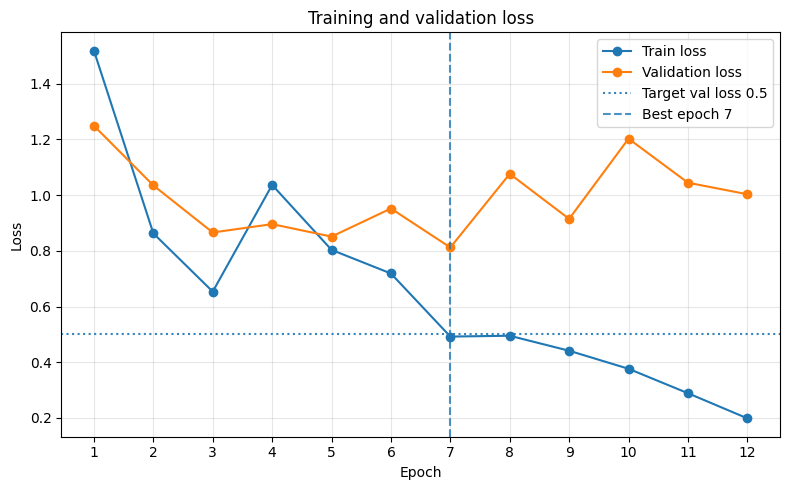

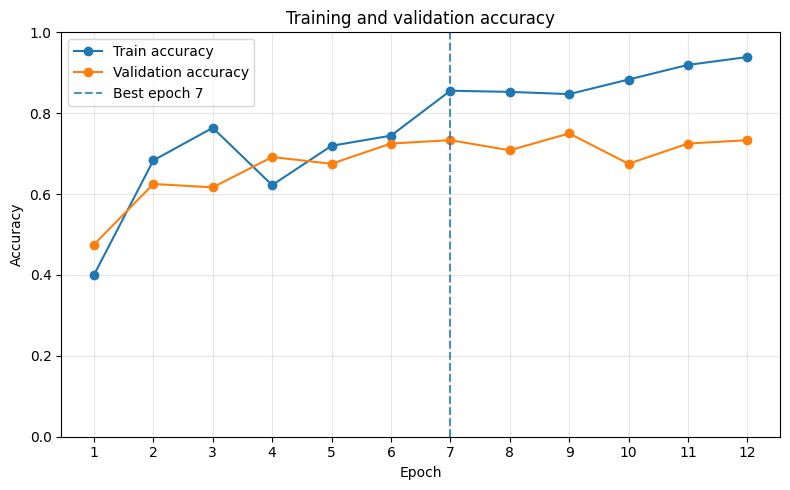

График loss сохранён: /content/drive/MyDrive/action_recognition_lite/runs/ucf101_lite_clean_cnn_lstm_target_val_loss_0_5/training_loss.png
График accuracy сохранён: /content/drive/MyDrive/action_recognition_lite/runs/ucf101_lite_clean_cnn_lstm_target_val_loss_0_5/training_accuracy.png
Целевой validation loss 0.5 не достигнут за этот запуск. Используй best.pt; для следующей попытки увеличь EPOCHS или снизь VAL_RATIO.
Главный checkpoint для инференса: /content/drive/MyDrive/action_recognition_lite/runs/ucf101_lite_clean_cnn_lstm_target_val_loss_0_5/best.pt


In [14]:

# Ячейка 12. Обучение + target validation loss + early stopping + графики

assert EPOCHS >= MIN_EPOCHS, "EPOCHS должен быть не меньше MIN_EPOCHS."
assert MIN_EPOCHS >= 10, "Для требования курсовой MIN_EPOCHS должен быть минимум 10."
assert VIDEOS_PER_CLEAN_CLASS >= 100, "Для этой версии требуется минимум 100 видео на каждый очищенный класс."
assert MAX_TRAIN_BATCHES is None, "MAX_TRAIN_BATCHES должен быть None, иначе это debug, а не обучение на всех 100 видео/класс."
assert MAX_VAL_BATCHES is None, "MAX_VAL_BATCHES должен быть None, иначе валидация будет неполной."

import matplotlib.pyplot as plt
from contextlib import nullcontext

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

# Новый AMP API без FutureWarning, с fallback для старых версий PyTorch.
try:
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP and torch.cuda.is_available())
except TypeError:
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP and torch.cuda.is_available())

def autocast_context():
    if USE_AMP and torch.cuda.is_available():
        try:
            return torch.amp.autocast("cuda")
        except TypeError:
            return torch.cuda.amp.autocast()
    return nullcontext()

def make_optimizer(stage: str):
    """Создаёт optimizer для этапа frozen или finetune."""
    if stage == "frozen":
        params = [p for p in model.parameters() if p.requires_grad]
        return torch.optim.AdamW(params, lr=HEAD_LR_FROZEN, weight_decay=WEIGHT_DECAY)

    if stage == "finetune":
        head_params = [p for p in model.lstm.parameters() if p.requires_grad]
        cnn_params = [p for p in model.cnn.parameters() if p.requires_grad]
        return torch.optim.AdamW(
            [
                {"params": head_params, "lr": HEAD_LR_FINETUNE},
                {"params": cnn_params, "lr": CNN_LR_FINETUNE},
            ],
            weight_decay=WEIGHT_DECAY,
        )

    raise ValueError(f"Unknown optimizer stage: {stage}")

optimizer = make_optimizer("frozen")
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
)

current_stage = "frozen"

def get_current_lr():
    return ";".join([f"{g['lr']:.2e}" for g in optimizer.param_groups])

def switch_to_finetune_if_needed(epoch: int):
    """На нужной эпохе размораживает верхний блок CNN и пересоздаёт optimizer/scheduler."""
    global optimizer, scheduler, current_stage
    if current_stage == "frozen" and epoch >= UNFREEZE_CNN_AT_EPOCH:
        print("\n=== Fine-tuning: размораживаю верхние CNN-блоки ===")
        print("TRAINABLE_CNN_BLOCKS:", TRAINABLE_CNN_BLOCKS)
        model.cnn.unfreeze_blocks(TRAINABLE_CNN_BLOCKS)
        optimizer = make_optimizer("finetune")
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
        )
        current_stage = "finetune"
        print_trainable_summary(model)
        print("LR groups:", get_current_lr())


def batch_correct_count(logits, labels):
    preds = logits.argmax(dim=1)
    return int((preds == labels).sum().item())


def run_epoch_train(epoch: int):
    model.train()
    if current_stage == "frozen":
        model.cnn.eval()
    else:
        model.cnn.set_frozen_bn_eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"train epoch {epoch} [{current_stage}]")

    for step, (videos, labels) in pbar:
        if MAX_TRAIN_BATCHES is not None and step >= MAX_TRAIN_BATCHES:
            break

        videos = videos.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        batch_size = labels.size(0)

        optimizer.zero_grad(set_to_none=True)

        with autocast_context():
            logits = model(videos)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad],
            max_norm=GRAD_CLIP_NORM,
        )

        scaler.step(optimizer)
        scaler.update()

        total_loss += float(loss.item()) * batch_size
        total_correct += batch_correct_count(logits.detach(), labels)
        total_examples += batch_size

        avg_loss = total_loss / max(total_examples, 1)
        avg_acc = total_correct / max(total_examples, 1)
        pbar.set_postfix(loss=avg_loss, acc=avg_acc, lr=get_current_lr())

    return total_loss / total_examples, total_correct / total_examples


@torch.no_grad()
def run_epoch_val(epoch: int):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    pbar = tqdm(enumerate(val_loader), total=len(val_loader), desc=f"val epoch {epoch}")

    for step, (videos, labels) in pbar:
        if MAX_VAL_BATCHES is not None and step >= MAX_VAL_BATCHES:
            break

        videos = videos.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        batch_size = labels.size(0)

        with autocast_context():
            logits = model(videos)
            loss = criterion(logits, labels)

        total_loss += float(loss.item()) * batch_size
        total_correct += batch_correct_count(logits, labels)
        total_examples += batch_size

        avg_loss = total_loss / max(total_examples, 1)
        avg_acc = total_correct / max(total_examples, 1)
        pbar.set_postfix(loss=avg_loss, acc=avg_acc)

    return total_loss / total_examples, total_correct / total_examples


def plot_training_history(history_df: pd.DataFrame, out_dir: Path, best_epoch: int | None = None):
    """Строит и сохраняет два отдельных графика: loss и accuracy."""
    out_dir.mkdir(parents=True, exist_ok=True)

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")
    plt.axhline(TARGET_VAL_LOSS, linestyle=":", alpha=0.9, label=f"Target val loss {TARGET_VAL_LOSS}")
    if best_epoch is not None:
        plt.axvline(best_epoch, linestyle="--", alpha=0.8, label=f"Best epoch {best_epoch}")
    plt.title("Training and validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.xticks(history_df["epoch"].tolist())
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    loss_path = out_dir / "training_loss.png"
    plt.savefig(loss_path, dpi=160)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_acc"], marker="o", label="Train accuracy")
    plt.plot(history_df["epoch"], history_df["val_acc"], marker="o", label="Validation accuracy")
    if best_epoch is not None:
        plt.axvline(best_epoch, linestyle="--", alpha=0.8, label=f"Best epoch {best_epoch}")
    plt.title("Training and validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.xticks(history_df["epoch"].tolist())
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    acc_path = out_dir / "training_accuracy.png"
    plt.savefig(acc_path, dpi=160)
    plt.show()

    print("График loss сохранён:", loss_path)
    print("График accuracy сохранён:", acc_path)


history = []
best_val_loss = float("inf")
best_val_acc = -1.0
best_epoch = None
epochs_without_improvement = 0
stopped_early = False
target_reached = False
target_epoch = None

for epoch in range(1, EPOCHS + 1):
    switch_to_finetune_if_needed(epoch)

    train_loss, train_acc = run_epoch_train(epoch)
    val_loss, val_acc = run_epoch_val(epoch)
    current_lr = get_current_lr()

    row = {
        "epoch": epoch,
        "stage": current_stage,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "lr": current_lr,
    }
    history.append(row)
    print(row)

    scheduler.step(val_loss)

    last_ckpt = {
        "model_state": model.state_dict(),
        "class_to_idx": class_to_idx,
        "idx_to_class": idx_to_class,
        "config": {
            "frames_per_clip": FRAMES_PER_CLIP,
            "image_size": IMAGE_SIZE,
            "groups_ucf101": UCF101_GROUPS,
            "groups_hmdb51": HMDB51_GROUPS,
            "videos_per_clean_class": VIDEOS_PER_CLEAN_CLASS,
            "val_ratio": VAL_RATIO,
            "test_ratio": TEST_RATIO,
            "max_epochs": EPOCHS,
            "min_epochs": MIN_EPOCHS,
            "target_val_loss": TARGET_VAL_LOSS,
            "early_stopping_patience": EARLY_STOPPING_PATIENCE,
            "dropout": DROPOUT,
            "weight_decay": WEIGHT_DECAY,
            "label_smoothing": LABEL_SMOOTHING,
            "grad_clip_norm": GRAD_CLIP_NORM,
            "stage1_frozen_epochs": STAGE1_FROZEN_EPOCHS,
            "trainable_cnn_blocks": TRAINABLE_CNN_BLOCKS,
            "head_lr_frozen": HEAD_LR_FROZEN,
            "head_lr_finetune": HEAD_LR_FINETUNE,
            "cnn_lr_finetune": CNN_LR_FINETUNE,
            "architecture": "CNNFeatureExtractor + LSTMTemporalModel inside one CNNLSTMActionRecognizer",
            "use_ucf101": USE_UCF101,
            "use_hmdb51": USE_HMDB51,
        },
        "history": history,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_val_acc": best_val_acc,
        "target_reached": target_reached,
        "target_epoch": target_epoch,
    }
    torch.save(last_ckpt, OUT_DIR / "last.pt")

    improved = val_loss < (best_val_loss - EARLY_STOPPING_MIN_DELTA)
    if improved:
        best_val_loss = val_loss
        best_val_acc = val_acc
        best_epoch = epoch
        epochs_without_improvement = 0
        best_ckpt = dict(last_ckpt)
        best_ckpt["best_epoch"] = best_epoch
        best_ckpt["best_val_loss"] = best_val_loss
        best_ckpt["best_val_acc"] = best_val_acc
        torch.save(best_ckpt, OUT_DIR / "best.pt")
        print(f"saved best.pt by val_loss: epoch={best_epoch}, val_loss={best_val_loss:.4f}, val_acc={best_val_acc:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"no val_loss improvement: {epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}")

    if (not target_reached) and val_loss <= TARGET_VAL_LOSS:
        target_reached = True
        target_epoch = epoch
        torch.save(last_ckpt, OUT_DIR / "target_loss_0_5.pt")
        print(f"TARGET REACHED: val_loss={val_loss:.4f} <= {TARGET_VAL_LOSS:.2f} на эпохе {epoch}")
    if epoch >= MIN_EPOCHS:
        if target_reached and epochs_without_improvement >= 2:
            stopped_early = True
            print(
                f"Early stopping after target: target val_loss был достигнут на эпохе {target_epoch}; "
                f"лучший checkpoint: epoch={best_epoch}, val_loss={best_val_loss:.4f}, val_acc={best_val_acc:.4f}"
            )
            break

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            stopped_early = True
            print(
                f"Early stopping: validation loss не улучшался {EARLY_STOPPING_PATIENCE} эпох подряд. "
                f"Лучший checkpoint: epoch={best_epoch}, val_loss={best_val_loss:.4f}, val_acc={best_val_acc:.4f}"
            )
            break

history_df = pd.DataFrame(history)
history_df.to_csv(OUT_DIR / "history.csv", index=False)

summary = {
    "stopped_early": stopped_early,
    "target_val_loss": TARGET_VAL_LOSS,
    "target_reached": target_reached,
    "target_epoch": target_epoch,
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "best_val_acc": best_val_acc,
    "epochs_ran": len(history),
    "best_checkpoint": str(OUT_DIR / "best.pt"),
    "target_checkpoint": str(OUT_DIR / "target_loss_0_5.pt") if target_reached else "not_reached",
    "last_checkpoint": str(OUT_DIR / "last.pt"),
}
pd.Series(summary).to_csv(OUT_DIR / "training_summary.csv")

print("История обучения:")
display(history_df)
print("Итог:")
print(summary)

plot_training_history(history_df, OUT_DIR, best_epoch=best_epoch)

if target_reached:
    print("Целевой validation loss достигнут. Для инференса используй best.pt или target_loss_0_5.pt:", OUT_DIR)
else:
    print("Целевой validation loss 0.5 не достигнут за этот запуск. Используй best.pt; для следующей попытки увеличь EPOCHS или снизь VAL_RATIO.")
print("Главный checkpoint для инференса:", OUT_DIR / "best.pt")


In [15]:
# Ячейка 13. Финальная проверка best.pt на тестовой выборке

from sklearn.metrics import classification_report, confusion_matrix

best_ckpt_path = OUT_DIR / "best.pt"
if not best_ckpt_path.exists():
    raise FileNotFoundError(f"Не найден best.pt: {best_ckpt_path}. Сначала запусти ячейку обучения.")
try:
    ckpt = torch.load(best_ckpt_path, map_location=device, weights_only=False)
except TypeError:
    ckpt = torch.load(best_ckpt_path, map_location=device)

model.load_state_dict(ckpt["model_state"])
model.eval()

@torch.no_grad()
def run_epoch_test():
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    y_true = []
    y_pred = []

    pbar = tqdm(enumerate(test_loader), total=len(test_loader), desc="test best.pt")

    for step, (videos, labels) in pbar:
        videos = videos.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        batch_size = labels.size(0)

        with autocast_context():
            logits = model(videos)
            loss = criterion(logits, labels)

        preds = logits.argmax(dim=1)

        total_loss += float(loss.item()) * batch_size
        total_correct += int((preds == labels).sum().item())
        total_examples += batch_size

        y_true.extend(labels.detach().cpu().tolist())
        y_pred.extend(preds.detach().cpu().tolist())

        pbar.set_postfix(
            loss=total_loss / max(total_examples, 1),
            acc=total_correct / max(total_examples, 1),
        )

    test_loss = total_loss / total_examples
    test_acc = total_correct / total_examples
    return test_loss, test_acc, y_true, y_pred


test_loss, test_acc, y_true, y_pred = run_epoch_test()

print("Финальная проверка best.pt на test-выборке")
print("TEST LOSS:", test_loss)
print("TEST ACCURACY:", test_acc)
print("TEST VIDEOS:", len(test_df))

# Отчёт по классификации.
report_text = classification_report(
    y_true,
    y_pred,
    target_names=clean_classes,
    digits=4,
    zero_division=0,
)
print(report_text)

# Матрица ошибок.
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(clean_classes))))
cm_df = pd.DataFrame(cm, index=clean_classes, columns=clean_classes)

test_summary = {
    "best_checkpoint": str(best_ckpt_path),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "test_videos": int(len(test_df)),
    "classes": ", ".join(clean_classes),
}

pd.DataFrame([test_summary]).to_csv(OUT_DIR / "test_summary.csv", index=False)
cm_df.to_csv(OUT_DIR / "test_confusion_matrix.csv")
(OUT_DIR / "test_classification_report.txt").write_text(report_text, encoding="utf-8")

# Сохраняем предсказания по отдельным видео.
test_predictions = test_df.reset_index(drop=True).copy()
test_predictions["true_label"] = y_true
test_predictions["pred_label"] = y_pred
test_predictions["true_class"] = [idx_to_class[i] for i in y_true]
test_predictions["pred_class"] = [idx_to_class[i] for i in y_pred]
test_predictions["correct"] = test_predictions["true_label"] == test_predictions["pred_label"]
test_predictions.to_csv(OUT_DIR / "test_predictions.csv", index=False)

print("Test summary сохранён:", OUT_DIR / "test_summary.csv")
print("Classification report сохранён:", OUT_DIR / "test_classification_report.txt")
print("Confusion matrix сохранена:", OUT_DIR / "test_confusion_matrix.csv")
print("Predictions сохранены:", OUT_DIR / "test_predictions.csv")

display(pd.DataFrame([test_summary]))
display(cm_df)


test best.pt:   0%|          | 0/30 [00:00<?, ?it/s]

Финальная проверка best.pt на test-выборке
TEST LOSS: 0.6893880277872085
TEST ACCURACY: 0.75
TEST VIDEOS: 120
              precision    recall  f1-score   support

  ball_sport     0.7619    0.8000    0.7805        20
    exercise     0.8462    0.5500    0.6667        20
        jump     0.6957    0.8000    0.7442        20
       music     0.7200    0.9000    0.8000        20
      strike     0.5714    0.6000    0.5854        20
water_action     1.0000    0.8500    0.9189        20

    accuracy                         0.7500       120
   macro avg     0.7659    0.7500    0.7493       120
weighted avg     0.7659    0.7500    0.7493       120

Test summary сохранён: /content/drive/MyDrive/action_recognition_lite/runs/ucf101_lite_clean_cnn_lstm_target_val_loss_0_5/test_summary.csv
Classification report сохранён: /content/drive/MyDrive/action_recognition_lite/runs/ucf101_lite_clean_cnn_lstm_target_val_loss_0_5/test_classification_report.txt
Confusion matrix сохранена: /content/drive/MyD

,best_checkpoint,test_loss,test_accuracy,test_videos,classes
0,/content/drive/MyDrive/action_recognition_lite...,0.689388,0.75,120,"ball_sport, exercise, jump, music, strike, wat..."


,ball_sport,exercise,jump,music,strike,water_action
ball_sport,16,0,1,2,1,0
exercise,2,11,3,0,4,0
jump,2,0,16,0,2,0
music,0,1,0,18,1,0
strike,1,1,2,4,12,0
water_action,0,0,1,1,1,17


In [20]:
# Ячейка 14. Инференс на одном видеофайле

@torch.no_grad()
def predict_video_file(video_path: str, ckpt_path: Optional[str] = None, topk: int = 5):
    if ckpt_path is not None:
        ckpt = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt["model_state"])
        raw_idx_to_class = ckpt["idx_to_class"]
        local_idx_to_class = {int(k): v for k, v in raw_idx_to_class.items()}
    else:
        local_idx_to_class = idx_to_class

    model.eval()
    clip = read_video_clip_cv2(video_path, FRAMES_PER_CLIP, IMAGE_SIZE).unsqueeze(0).to(device)

    with autocast_context():
        logits = model(clip)
        probs = logits.softmax(dim=1).squeeze(0).detach().cpu()

    k = min(topk, probs.numel())
    values, indices = torch.topk(probs, k=k)
    result = []
    for prob, idx in zip(values.tolist(), indices.tolist()):
        result.append((local_idx_to_class[int(idx)], float(prob)))
    return result
predict_video_file("/content/user_video.mp4", ckpt_path=str(OUT_DIR / "best.pt"))

[('strike', 0.837543785572052),
 ('exercise', 0.0949615016579628),
 ('jump', 0.0414147675037384),
 ('music', 0.020105257630348206),
 ('ball_sport', 0.0036721816286444664)]

In [18]:
# Загрузка пользовательского видео с YouTube

!pip -q install -U yt-dlp

import glob
import subprocess
from pathlib import Path

YOUTUBE_URL = "https://www.youtube.com/shorts/g7_KDQlU5ds"

# удаляем старые попытки
for f in glob.glob("/content/user_video.*"):
    Path(f).unlink()

cmd = [
    "yt-dlp",
    "-f", "bv*[height<=360]+ba/b[height<=360]/best[height<=360]/best",
    "--merge-output-format", "mp4",
    "--no-playlist",
    "-o", "/content/user_video.%(ext)s",
    YOUTUBE_URL
]

result = subprocess.run(cmd, capture_output=True, text=True)

print("STDOUT:")
print(result.stdout)
print("STDERR:")
print(result.stderr)

video_files = glob.glob("/content/user_video.*")
print("Найденные файлы:", video_files)

if len(video_files) == 0:
    raise FileNotFoundError("Видео не скачалось. Проверь ссылку или загрузи mp4 вручную.")

user_video_path = video_files[0]
print("Видео загружено:", user_video_path)

STDOUT:
[youtube] Extracting URL: https://www.youtube.com/shorts/g7_KDQlU5ds
[youtube] g7_KDQlU5ds: Downloading webpage
[youtube] g7_KDQlU5ds: Downloading android vr player API JSON
[info] g7_KDQlU5ds: Downloading 1 format(s): 278+251
[download] Destination: /content/user_video.f278.webm

[download]   0.7% of  142.65KiB at  Unknown B/s ETA Unknown
[download]   2.1% of  142.65KiB at  Unknown B/s ETA Unknown
[download]   4.9% of  142.65KiB at    4.96MiB/s ETA 00:00  
[download]  10.5% of  142.65KiB at    8.02MiB/s ETA 00:00
[download]  21.7% of  142.65KiB at    4.37MiB/s ETA 00:00
[download]  44.2% of  142.65KiB at    2.90MiB/s ETA 00:00
[download]  89.0% of  142.65KiB at    5.68MiB/s ETA 00:00
[download] 100.0% of  142.65KiB at    6.23MiB/s ETA 00:00
[download] 100% of  142.65KiB in 00:00:00 at 1.37MiB/s   
[download] Destination: /content/user_video.f251.webm

[download]   0.6% of  177.67KiB at  Unknown B/s ETA Unknown
[download]   1.7% of  177.67KiB at    2.72MiB/s ETA 00:00  
[downlo

In [19]:
result = predict_video_file(
    video_path=user_video_path,
    ckpt_path=str(OUT_DIR / "best.pt"),
    topk=5
)

print("Результат определения действия:")
for class_name, prob in result:
    print(f"{class_name}: {prob:.4f}")

Результат определения действия:
strike: 0.8375
exercise: 0.0950
jump: 0.0414
music: 0.0201
ball_sport: 0.0037
